**1.ZADATAK LAB4**

In [1]:
#importi
!rm -rf clone && git clone https://github.com/pui-sum-rv/lab4 clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 47 (delta 10), reused 37 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 3.36 MiB | 16.55 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

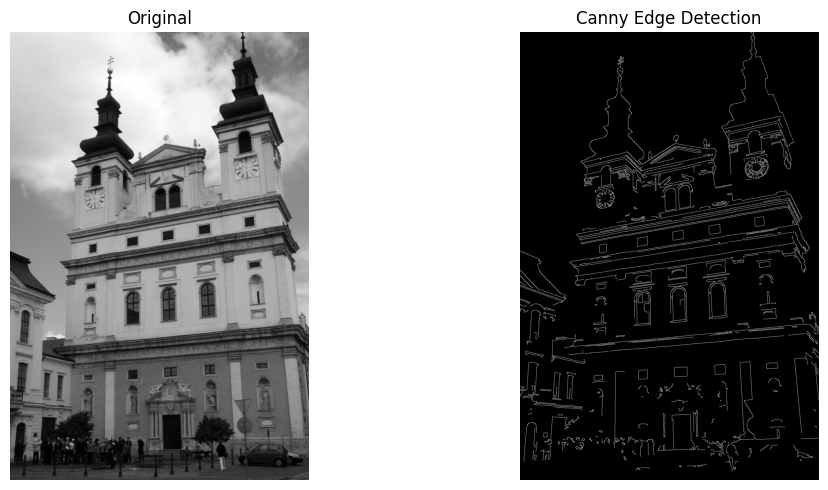

In [5]:
#task 1 - Canny edge detection
img = cv2.imread('images/building_2.jpg', cv2.IMREAD_GRAYSCALE)

#gaussian blur prije Canny
img_blur = cv2.GaussianBlur(img, (5, 5), 1)

#canny edge detection
edges = cv2.Canny(img_blur, 100, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edge Detection')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import os
print(os.listdir('images/'))

['chess.jpg', 'building_2.jpg', 'building_1.jpg', 'crossword.jpg', 'roma_2.jpg', 'one_coin.jpg', 'cells.jpg', 'woman_darkhair.png', 'roma_1.jpg', 'sudoku.png']


**2.ZADATAK LAB4**

In [6]:
#task 2 - Hough transformacija
import math

def draw_lines(img, lines):
    a, b, c = lines.shape
    for i in range(a):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0, y0 = a*rho, b*rho
        pt1 = (int(x0+1000*(-b)), int(y0+1000*(a)))
        pt2 = (int(x0-1000*(-b)), int(y0-1000*(a)))
        cv2.line(img, pt1, pt2, (255, 0, 0), 2, cv2.LINE_AA)
    return img

In [7]:
#ucitavanje slike krizaljke
img = cv2.imread('images/crossword.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#blur + Canny
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 1)
edges = cv2.Canny(img_blur, 100, 200)

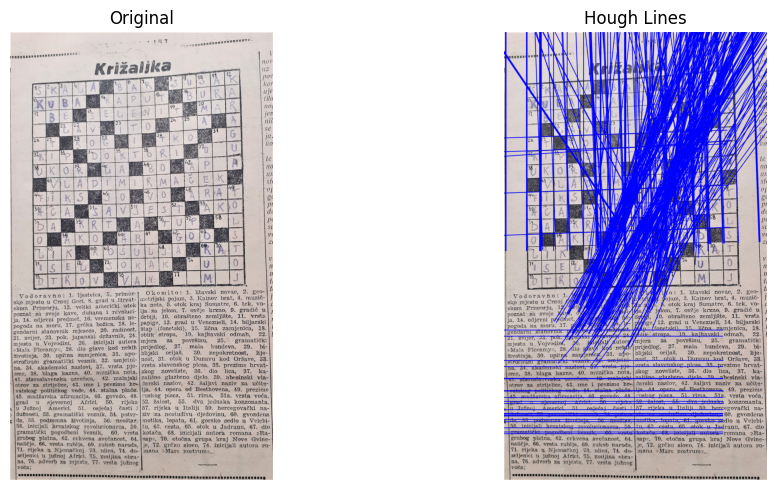

In [9]:
#hough transformacija
lines = cv2.HoughLines(edges, 1, math.pi/90, 300, np.array([]), 0, 0)

#crtanje linija na originalnoj slici
img_lines = img.copy()
img_lines = draw_lines(img_lines, lines)
img_lines_rgb = cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_lines_rgb)
axes[1].set_title('Hough Lines')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**3.ZADATAK LAB4**

In [10]:
#task 3 - Hough transformacija s theta = math.pi/180
img = cv2.imread('images/crossword.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#blur + Canny
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 1)
edges = cv2.Canny(img_blur, 100, 200)

In [17]:
#hough transformacija s drugačijim theta
lines = cv2.HoughLines(edges, 1, math.pi/180, 350, np.array([]), 0, 0)

#crtanje linija
img_lines = img.copy()
img_lines = draw_lines(img_lines, lines)
img_lines_rgb = cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB)

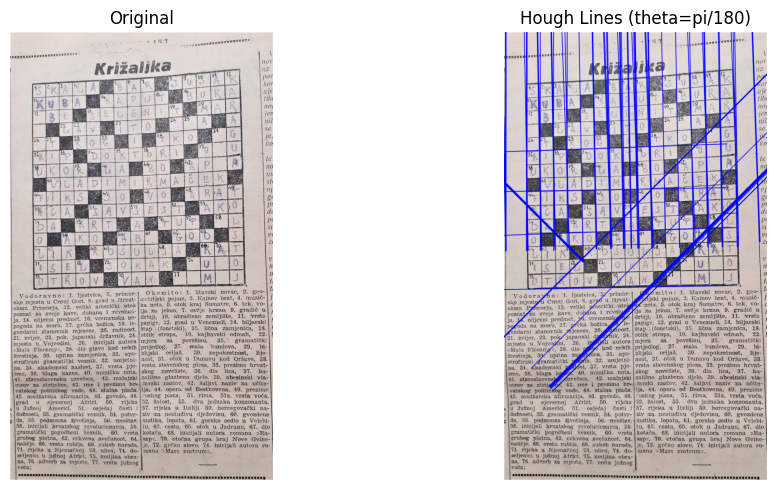

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_lines_rgb)
axes[1].set_title('Hough Lines (theta=pi/180)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**4.ZADATAK LAB4**

In [19]:
#task 4 - Harris corner detection
img = cv2.imread('images/crossword.jpg', cv2.IMREAD_GRAYSCALE)
img_color = cv2.imread('images/crossword.jpg')
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

#harris corner detection
corners = cv2.cornerHarris(img, 15, 3, 0.05)

In [20]:
#postavljanje piksela na 255 gdje je corner vrijednost veca od praga
img_corners = img_color_rgb.copy()
img_corners[corners > 0.0001 * corners.max()] = 255

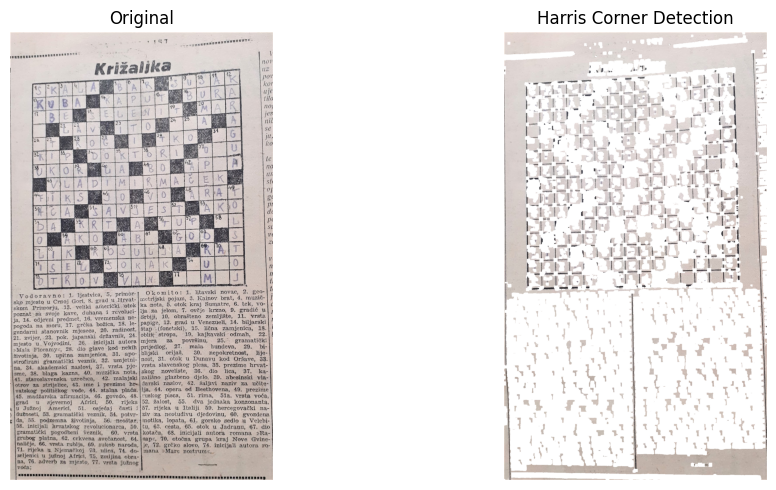

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_color_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_corners)
axes[1].set_title('Harris Corner Detection')
axes[1].axis('off')

plt.tight_layout()
plt.show()
